In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import glob

from XMA_finder import XMA_finder
from Cluster_CDF_conv import Cluster_cdf_conv
#from histo_plot_lower_vmax import histo_plot
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from pyspedas.cotrans_tools.minvar import minvar

#import modules
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib import cm
import matplotlib.colors as colors
from merka05_surface_eq_array_GIPM import merka05_surface_eq_array_GIPM
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import matplotlib.ticker as ticker
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Rectangle
from matplotlib.patches import FancyBboxPatch
from matplotlib.transforms import TransformedBbox
from matplotlib.collections import LineCollection
import matplotlib.collections as mcoll
import matplotlib.path as mpath

In [2]:
#import Cluster integrated CSVs, separated by spacecraft in order to match w/Fourier spectra
#import C1/C2/C3/C4 csvs and determine min/max power
#then go back to update the colourmap norm choice

##load Cluster CSVs

c1_file_list = []
c2_file_list = []
c3_file_list = []
c4_file_list = []

path = "/Users/roseatkinson/Documents/Cluster_Integrated_CSVs/Integrated_CSVs_2001/**"

for path in glob.glob(path, recursive=True):
    if '.csv' in path:
        if 'C1' in path:
            c1_file_list.append(path)
        if 'C2' in path:
            c2_file_list.append(path)   
        if 'C3' in path:
            c3_file_list.append(path)
        if 'C4' in path:
            c4_file_list.append(path)

cl_csvs = [c1_file_list, c2_file_list, c3_file_list, c4_file_list]
            
c1_dfs = []
c2_dfs = []
c3_dfs = []
c4_dfs = []

cl_dfs = [c1_dfs, c2_dfs, c3_dfs, c4_dfs]

for csv_list, df_list in zip(cl_csvs, cl_dfs):
    for file in csv_list:
        df = pd.read_csv(file,encoding='utf-8')
        df['datetime'] = pd.to_datetime(df['datetime'], format='mixed')
        df.set_index('datetime', inplace = True)
        df_list.append(df)

cl_1_df = pd.concat(c1_dfs)
cl_2_df = pd.concat(c2_dfs)
cl_3_df = pd.concat(c3_dfs)
cl_4_df = pd.concat(c4_dfs)

#Filtering: remove OMNI too far, current sheets, & null GIPM entries
cl_1_filtered = cl_1_df.loc[(cl_1_df['OMNI Dist from X line (mean)'] < 70) & (cl_1_df['Max IMF Deviation'] < 60) & (cl_1_df['GIPM X (OMNI mean)'].notnull())]
cl_2_filtered = cl_2_df.loc[(cl_2_df['OMNI Dist from X line (mean)'] < 70) & (cl_2_df['Max IMF Deviation'] < 60) & (cl_2_df['GIPM X (OMNI mean)'].notnull())]
cl_3_filtered = cl_3_df.loc[(cl_3_df['OMNI Dist from X line (mean)'] < 70) & (cl_3_df['Max IMF Deviation'] < 60) & (cl_3_df['GIPM X (OMNI mean)'].notnull())]
cl_4_filtered = cl_4_df.loc[(cl_4_df['OMNI Dist from X line (mean)'] < 70) & (cl_4_df['Max IMF Deviation'] < 60) & (cl_4_df['GIPM X (OMNI mean)'].notnull())]

cl_1_filtered_lowZ = cl_1_filtered.loc[(cl_1_filtered['GIPM Z (OMNI mean)'] < 5) & (cl_1_filtered['GIPM Z (OMNI mean)'] > -5)]
cl_2_filtered_lowZ = cl_2_filtered.loc[(cl_2_filtered['GIPM Z (OMNI mean)'] < 5) & (cl_2_filtered['GIPM Z (OMNI mean)'] > -5)]
cl_3_filtered_lowZ = cl_3_filtered.loc[(cl_3_filtered['GIPM Z (OMNI mean)'] < 5) & (cl_3_filtered['GIPM Z (OMNI mean)'] > -5)]
cl_4_filtered_lowZ = cl_4_filtered.loc[(cl_4_filtered['GIPM Z (OMNI mean)'] < 5) & (cl_4_filtered['GIPM Z (OMNI mean)'] > -5)]


In [5]:
#first off: looking at polarisation by taking ratio of power in two transverse components 
#will need to match the spectra to the Cluster GIPM measurement

#/Users/roseatkinson/Documents/Spectra_2001
#example file:
#'/Users/roseatkinson/Documents/Spectra_2001/FS_2001-02-02 19:14:00_C4.csv'
#iterate through filtered cluster datasets
#make new dataframe with the datetimes as the index and the results as columns
#then later join on df index to original df with the rest of the cluster data
cl_1_datetimes = []
cl_1_peak_para_freqs = []
cl_1_peak_perp_freqs = []
cl_1_ellipticity = []

cl_2_datetimes = []
cl_2_peak_para_freqs = []
cl_2_peak_perp_freqs = []
cl_2_ellipticity = []

cl_3_datetimes = []
cl_3_peak_para_freqs = []
cl_3_peak_perp_freqs = []
cl_3_ellipticity = []

cl_4_datetimes = []
cl_4_peak_para_freqs = []
cl_4_peak_perp_freqs = []
cl_4_ellipticity = []

#temporarily keeping loaded dfs for testing
#spectra_1_dfs = []
#spectra_2_dfs = []
#spectra_3_dfs = []
#spectra_4_dfs = []

df_list = [cl_1_filtered_lowZ, cl_2_filtered_lowZ, cl_3_filtered_lowZ, cl_4_filtered_lowZ]
sc_list = ['C1', 'C2', 'C3', 'C4']
dt_lists = [cl_1_datetimes, cl_2_datetimes, cl_3_datetimes, cl_4_datetimes]
para_freq_lists = [cl_1_peak_para_freqs, cl_2_peak_para_freqs, cl_3_peak_para_freqs, cl_4_peak_para_freqs]
perp_freq_lists = [cl_1_peak_perp_freqs, cl_2_peak_perp_freqs, cl_3_peak_perp_freqs, cl_4_peak_perp_freqs]
ellip_lists = [cl_1_ellipticity, cl_2_ellipticity, cl_3_ellipticity, cl_4_ellipticity]
#spec_lists = [spectra_1_dfs, spectra_2_dfs, spectra_3_dfs, spectra_4_dfs]

#, spec_list

for df, sc, dt_list, para_freq_list, perp_freq_list, ellip_list in zip(df_list, sc_list, dt_lists, para_freq_lists, perp_freq_lists, ellip_lists):

    for datetime in df.index:
        dt_list.append(datetime)
        filename = '/Users/roseatkinson/Documents/Spectra_2001_2003/FS_'+ str(datetime) + '_'+sc+'.csv'
        f_df = pd.read_csv(filename)
        #add column with total perpendicular power
        f_df['Perp Power'] = f_df['Perp 1 Power'] + f_df['Perp 2 Power']
        #find the index of peak compressive power
        max_para_pwr_idx = f_df[['Parallel Power']].idxmax()
        max_para_freq = f_df.loc[max_para_pwr_idx, 'Freq'].values[0]
        max_perp_pwr_idx = f_df[['Perp Power']].idxmax()
        max_perp_freq = f_df.loc[max_perp_pwr_idx, 'Freq'].values[0]
        para_freq_list.append(max_para_freq)
        perp_freq_list.append(max_perp_freq)
        
        ## Compute the power into the required frequency range using midpoint integration
        F_LOW,F_HIGH = 7e-3,1e-1
        #make np arrays of columns first
        freq = f_df['Freq'].to_numpy()
        p_perp_1 = f_df['Perp 1 Power'].to_numpy()
        p_perp_2 = f_df['Perp 2 Power'].to_numpy()
        mask = (freq>F_LOW) & (freq<F_HIGH)
        delta_f = freq[1] - freq[0]
        P_perp_1 = np.sum(p_perp_1[mask])*delta_f
        P_perp_2 = np.sum(p_perp_2[mask])*delta_f
    
        if P_perp_1 > P_perp_2:
            ratio = P_perp_1/P_perp_2
            ellip_list.append(ratio)
        else:
            ratio = P_perp_2/P_perp_1
            ellip_list.append(ratio)
        
#make new dfs

new_cl_1_df = pd.DataFrame({
    'time': cl_1_datetimes,
    'Peak Parallel Frequency': cl_1_peak_para_freqs,
    'Peak Perpendicular Frequency': cl_1_peak_perp_freqs,
    'Perp 1/Perp 2': cl_1_ellipticity
})

new_cl_1_df.set_index('time', inplace=True)

new_cl_2_df = pd.DataFrame({
    'time': cl_2_datetimes,
    'Peak Parallel Frequency': cl_2_peak_para_freqs,
    'Peak Perpendicular Frequency': cl_2_peak_perp_freqs,
    'Perp 1/Perp 2': cl_2_ellipticity
})

new_cl_2_df.set_index('time', inplace=True)

new_cl_3_df = pd.DataFrame({
    'time': cl_3_datetimes,
    'Peak Parallel Frequency': cl_3_peak_para_freqs,
    'Peak Perpendicular Frequency': cl_3_peak_perp_freqs,
    'Perp 1/Perp 2': cl_3_ellipticity
})

new_cl_3_df.set_index('time', inplace=True)

new_cl_4_df = pd.DataFrame({
    'time': cl_4_datetimes,
    'Peak Parallel Frequency': cl_4_peak_para_freqs,
    'Peak Perpendicular Frequency': cl_4_peak_perp_freqs,
    'Perp 1/Perp 2': cl_4_ellipticity
})

new_cl_4_df.set_index('time', inplace=True)

c1_full = cl_1_filtered_lowZ.join(new_cl_1_df)
c2_full = cl_2_filtered_lowZ.join(new_cl_2_df)
c3_full = cl_3_filtered_lowZ.join(new_cl_3_df)
c4_full = cl_4_filtered_lowZ.join(new_cl_4_df)


In [6]:
#C1 '2002-12-16 06:53:00'

TypeError: Cannot index by location index with a non-integer key

In [4]:
spec_0 = spectra_1_dfs[2]
    
idx_max = spec_0[['Parallel Power']].idxmax()

spec_0.loc[idx_max,'Freq'].values[0]

np.float64(0.0124860646599777)

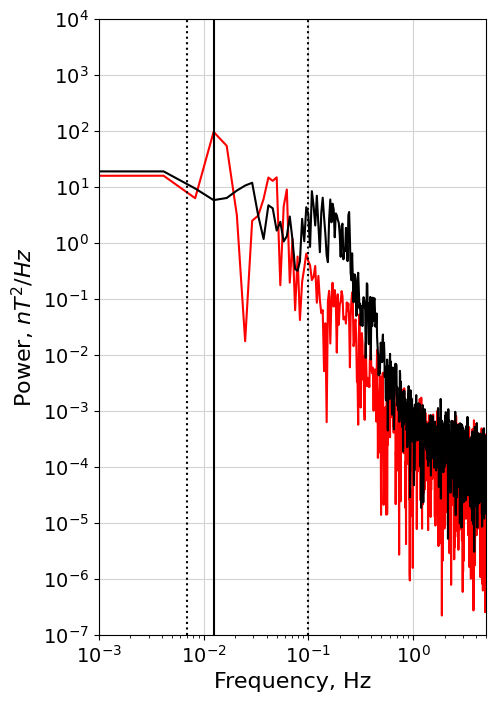

In [32]:
frequency = spec_0['Freq']
perp_power = spec_0['Perp 1 Power'] + spec_0['Perp 2 Power']
para_power = spec_0['Parallel Power']

idx_max_freq = spec_0[['Parallel Power']].idxmax()
max_freq = spec_0.loc[idx_max_freq,'Freq'].values[0]

int_lower_lim = 7*(10**(-3))
int_upper_lim = 100*(10**(-3))

fig, ax = plt.subplots(figsize = (5, 8))

#ax.set_title('2002-04-01 00:53:00')
ax.plot(frequency, para_power, color="red", label='Parallel Power')
ax.plot(frequency, perp_power, color="black", label='Perpendicular Power')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel('Power, $nT^2/Hz$')
ax.set_xlabel('Frequency, Hz')
ax.set_xlim(0.001, 5)
ax.set_ylim(0.0000001, 10000)
ax.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=15))
#ax.yaxis.set_minor_locator(ticker.LogLocator(base=10, numticks=10))
ax.vlines(x=max_freq, ymin = 0.0000001, ymax = 10000, linestyles='-', color='k', label='Lower Bound')
ax.vlines(x=int_lower_lim, ymin = 0.0000001, ymax = 10000, linestyles='dotted', color='k', label='Lower Bound')
ax.vlines(x=int_upper_lim, ymin = 0.0000001, ymax = 10000, linestyles='dotted', color='k', label='Upper Bound')
#ax.legend(loc='lower center')
plt.rc('xtick', labelsize=14)    # fontsize of the tick labels
plt.rc('ytick', labelsize=14) 
plt.rc('axes', labelsize=16) 

ax.set_axisbelow(True)
ax.yaxis.grid(color='lightgray')
ax.xaxis.grid(color='lightgray')

In [6]:
#testing 

cl_1_unfiltered = cl_1_df.loc[(cl_1_df['GIPM X (OMNI mean)'].notnull())]

temp_cl_1_datetimes = []
temp_cl_1_peak_freqs = []
temp_cl_1_ellipticity = []
temp_spec_list = []

for datetime in cl_1_unfiltered.index:
    temp_cl_1_datetimes.append(datetime)
    filename = '/Users/roseatkinson/Documents/Spectra_2001/FS_'+ str(datetime) + '_C1.csv'
    f_df = pd.read_csv(filename)
    temp_spec_list.append(f_df)
    #find the index of peak compressive power
    max_pwr_idx = f_df[['Parallel Power']].idxmax()
    max_freq = f_df.loc[max_pwr_idx, 'Freq'].values[0]
    temp_cl_1_peak_freqs.append(max_freq)
    
    ## Compute the power into the required frequency range using midpoint integration
    F_LOW,F_HIGH = 7e-3,1e-1
    #make np arrays of columns first
    freq = f_df['Freq'].to_numpy()
    p_perp_1 = f_df['Perp 1 Power'].to_numpy()
    p_perp_2 = f_df['Perp 2 Power'].to_numpy()
    mask = (freq>F_LOW) & (freq<F_HIGH)
    delta_f = freq[1] - freq[0]
    P_perp_1 = np.sum(p_perp_1[mask])*delta_f
    P_perp_2 = np.sum(p_perp_2[mask])*delta_f

    if P_perp_1 > P_perp_2:
        ratio = P_perp_1/P_perp_2
        temp_cl_1_ellipticity.append(ratio)
    else:
        ratio = P_perp_2/P_perp_1
        temp_cl_1_ellipticity.append(ratio)
        

temp_cl_1_df = pd.DataFrame({
    'time': temp_cl_1_datetimes,
    'Peak Frequency': temp_cl_1_peak_freqs,
    'Perp 1/Perp 2': temp_cl_1_ellipticity
})

temp_cl_1_df.set_index('time', inplace=True)
#will temporarily have to test with restrictions lifted!

fs_int_start = pd.to_datetime('2001-04-23 05:08:00')
fs_int_end = pd.to_datetime('2001-04-23 05:12:00')

sw_int_start = pd.to_datetime('2001-04-23 03:52:00')
sw_int_end = pd.to_datetime('2001-04-23 03:56:00')

#read out results for eastwood intervals

#Eastwood Intervals: 2001-04-23 03:52:00 (Pristine)
#2001-04-23 05:10:00

fs_freq = temp_cl_1_df.loc[fs_int_start, 'Peak Frequency']
sw_freq = temp_cl_1_df.loc[sw_int_start, 'Peak Frequency']
print(temp_cl_1_df.loc[fs_int_start, 'Perp 1/Perp 2'])
print(temp_cl_1_df.loc[sw_int_start, 'Perp 1/Perp 2'])


1.0334368179370408
2.9819842419351854


In [7]:
#further testing 

#load in Cluster CDFs for hodogram/MVA purposes
intervals_df = Cluster_cdf_conv('/Users/roseatkinson/Documents/CSA_Download_20260211_1852/C1_CP_FGM_FULL/C1_CP_FGM_FULL__20010423_000000_20010423_120000_V140306.cdf', 'C1')
sw_df = intervals_df.loc[(intervals_df.index > sw_int_start) & (intervals_df.index < sw_int_end)]
fs_df = intervals_df.loc[(intervals_df.index > fs_int_start) & (intervals_df.index < fs_int_end)]

filepath_sw = '/Users/roseatkinson/Documents/Spectra_2001/FS_2001-04-23 03:52:00_C1.csv'
filepath_fs = '/Users/roseatkinson/Documents/Spectra_2001/FS_2001-04-23 05:08:00_C1.csv'

sw_fs_df = pd.read_csv(filepath_sw)
fs_fs_df = pd.read_csv(filepath_fs)

In [8]:
fs_df.columns

Index(['Bx_gse', 'By_gse', 'Bz_gse', 'B_mag', 'X_gse', 'Y_gse', 'Z_gse',
       'R_GSE'],
      dtype='str')

minvar vectors: 
max: [-0.26525543 -0.57321292  0.77528479]
int: [0.72794935 0.40820562 0.55087014]
min: [-0.63224149  0.71048936  0.30899122]
eigenvalues: 
[5.39587876 3.46657504 0.79608406]
ellipticity: 1.5565446264520355
linearity: 4.354533907539936


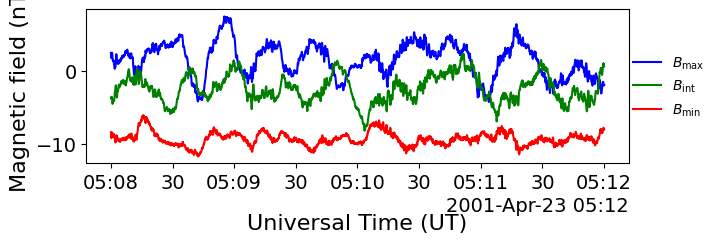

In [33]:
#apply pyspedas code to cut-down window

times = fs_df.index.array

bx = fs_df['Bx_gse'].values

by = fs_df['By_gse'].values

bz = fs_df['Bz_gse'].values

vrot, v, w = minvar(np.column_stack([bx,by,bz]))

fig = plt.figure(figsize=(7,2))

plt.plot(times,vrot[:,0],c="blue",label="$B_\\mathrm{max}$")

plt.plot(times,vrot[:,1],c="green",label="$B_\\mathrm{int}$")

plt.plot(times,vrot[:,2],c="red",label="$B_\\mathrm{min}$")

plt.legend(frameon = False,loc='center left', bbox_to_anchor=(0.985, 0.5))

plt.ylabel("Magnetic field (nT)")

plt.xlabel("Universal Time (UT)",labelpad=15)

print("minvar vectors: ")

print("max: ",end='')

print(v[:,0])

print("int: ",end='')

print(v[:,1])

print("min: ",end='')

print(v[:,2])

print("eigenvalues: ")

print(w)

print("ellipticity:", w[0]/w[1])
print("linearity:", w[1]/w[2])

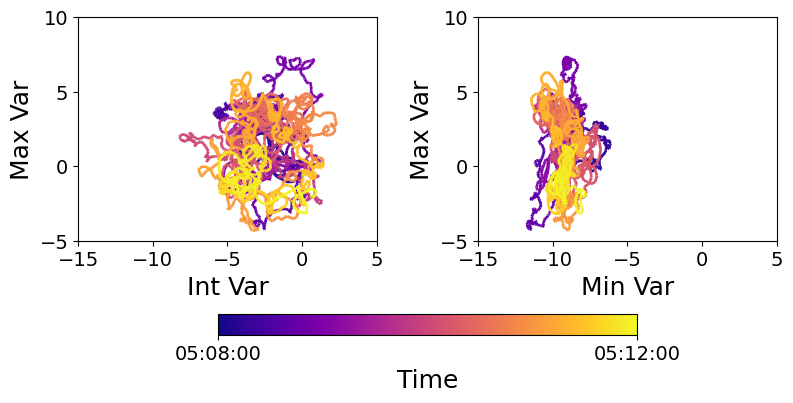

In [30]:
#transform whole dataset including whistlers to new data frame

data = np.column_stack([bx,by,bz])
vrot_1 = np.array([np.dot(row, v) for row in data])

#nesting figs to make it look better
#colour coding

vr_max = vrot_1[:,0]
vr_int = vrot_1[:,1]
vr_min = vrot_1[:,2]

vr_max_df = pd.DataFrame(vr_max, columns = ['max'])
vr_int_df = pd.DataFrame(vr_int, columns = ['int'])
vr_min_df = pd.DataFrame(vr_min, columns = ['min'])

vr_index = np.array(vr_max_df.index)

# Create a set of line segments so that we can color them individually
# This creates the points as an N x 1 x 2 array so that we can stack points
# together easily to get the segments. The segments array for line collection
# needs to be (numlines) x (points per line) x 2 (for x and y)
points_1 = np.array([vr_int, vr_max]).T.reshape(-1, 1, 2)
segments_1 = np.concatenate([points_1[:-1], points_1[1:]], axis=1)

points_2 = np.array([vr_min, vr_max]).T.reshape(-1, 1, 2)
segments_2 = np.concatenate([points_2[:-1], points_2[1:]], axis=1)
last_tick = vr_index.max()


# gridspec inside gridspec
fig = plt.figure(layout='constrained', figsize=(8, 4))
subfigs = fig.subfigures(1, 1, wspace=0.07)

axsLeft = subfigs.subplots(1, 2, sharey=False)

# Create a continuous norm to map from data points to colors
#norm = plt.Normalize(vr_max_df.index.min(), vr_max_df.index.max())
norm = plt.Normalize(vr_index.min(), vr_index.max())
lc1 = LineCollection(segments_1, cmap='plasma', norm=norm)
# Set the values used for colormapping
lc1.set_array(vr_index)
lc1.set_linewidth(2)
line = axsLeft[0].add_collection(lc1)
axsLeft[0].set_ylim(-5,10)
axsLeft[0].set_xlim(-15,5)
axsLeft[0].set_aspect('equal')
axsLeft[0].set_ylabel("Max Var")
axsLeft[0].set_xlabel("Int Var")

lc2 = LineCollection(segments_2, cmap='plasma', norm=norm)
# Set the values used for colormapping
lc2.set_array(vr_index)
lc2.set_linewidth(2)
line = axsLeft[1].add_collection(lc2)

axsLeft[1].set_ylim(-5,10)
axsLeft[1].set_xlim(-15,5)
axsLeft[1].set_aspect('equal')
axsLeft[1].set_ylabel("Max Var")
axsLeft[1].set_xlabel("Min Var")

colorbar = subfigs.colorbar(line, shrink=0.6, ax=axsLeft, location='bottom', label='Time', ticks = [0, last_tick])
start_label = fs_int_start.time()
end_label = fs_int_end.time()
colorbar.set_ticklabels([start_label, end_label])

#ax.plot(vrot_1[:,2],vrot_1[:,0], color='k')

#fig.align_labels()

plt.show()


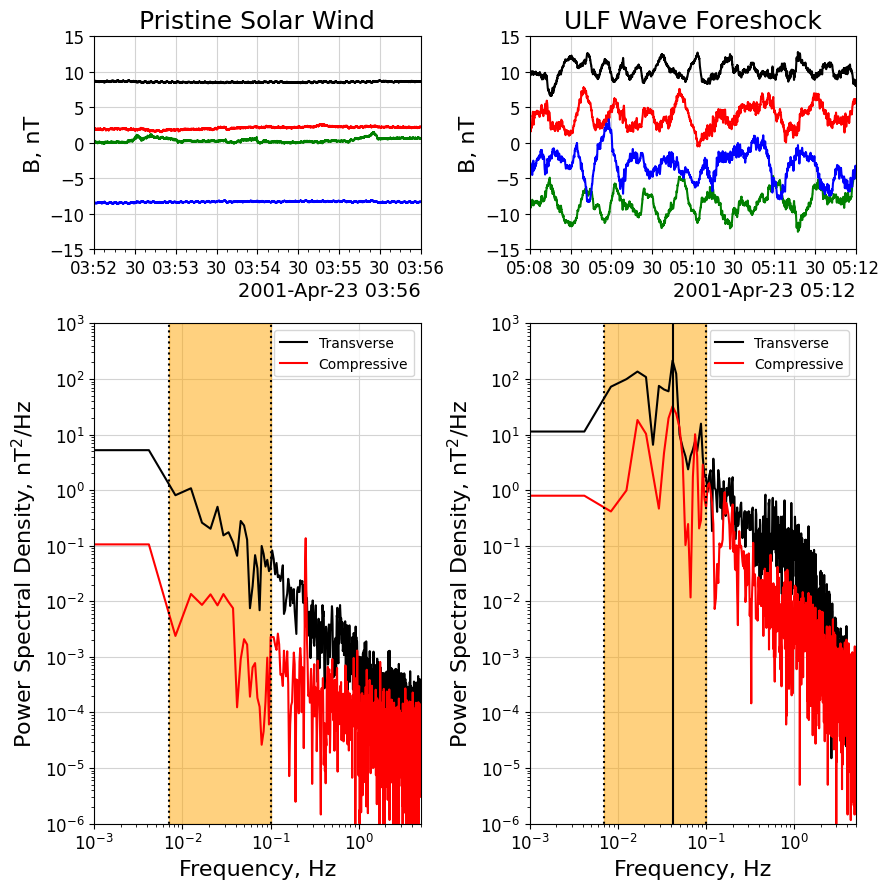

In [15]:
# Create a figure
fig = plt.figure(figsize=(9, 9))

locator = mdates.AutoDateLocator(minticks=3, maxticks=5)
formatter = mdates.ConciseDateFormatter(locator)

# Define a gridspec layout
#gs = gridspec(3, 2, figure=fig)
gs = fig.add_gridspec(nrows=3, ncols=2)

# Add subplots with custom spans
#Subplots are positioned and sized using slicing 
#(e.g., gs[0, 0:2] spans the first two columns of the first row).
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1:, 0])
ax4 = fig.add_subplot(gs[1:, 1])

plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 18

# Add data to each subplot
ax1.plot(sw_df.index, sw_df['Bx_gse'], color = 'red')
ax1.plot(sw_df.index, sw_df['By_gse'], color = 'green')
ax1.plot(sw_df.index, sw_df['Bz_gse'], color = 'blue')
ax1.plot(sw_df.index, sw_df['B_mag'], color = 'k')
ax1.set_ylim(-15, 15)
ax1.set_xlim(sw_int_start, sw_int_end)
ax1.xaxis.set_major_formatter(formatter)
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.xaxis.set_tick_params(labelsize=12)
ax1.yaxis.set_tick_params(labelsize=12)
ax1.set_ylabel(r'B, nT')
ax1.set_title('Pristine Solar Wind')
ax1.set_axisbelow(True)
ax1.yaxis.grid(color='lightgray')
ax1.xaxis.grid(color='lightgray')

ax2.plot(fs_df.index, fs_df['Bx_gse'], color = 'red')
ax2.plot(fs_df.index, fs_df['By_gse'], color = 'green')
ax2.plot(fs_df.index, fs_df['Bz_gse'], color = 'blue')
ax2.plot(fs_df.index, fs_df['B_mag'], color = 'k')
ax2.set_ylim(-15, 15)
ax2.set_xlim(fs_int_start, fs_int_end)
ax2.xaxis.set_major_formatter(formatter)
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.xaxis.set_tick_params(labelsize=12)
ax2.yaxis.set_tick_params(labelsize=12)
ax2.set_ylabel(r'B, nT')
ax2.set_title('ULF Wave Foreshock')
ax2.set_axisbelow(True)
ax2.yaxis.grid(color='lightgray')
ax2.xaxis.grid(color='lightgray')

int_lower_lim = 7*(10**(-3))
int_upper_lim = 100*(10**(-3))

sw_perp_tot = sw_fs_df['Perp 1 Power'] + sw_fs_df['Perp 2 Power']

ax3.plot(sw_fs_df['Freq'], sw_perp_tot, color="black", label='Transverse')
ax3.plot(sw_fs_df['Freq'], sw_fs_df['Parallel Power'], color="red", label='Compressive')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_ylabel(r'Power Spectral Density, $\mathrm{nT^2/Hz}$')
ax3.set_xlabel('Frequency, Hz')
ax3.set_xlim(0.001, 5)
ax3.set_ylim(0.000001, 1000)
ax3.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=15))
ax3.vlines(x=int_lower_lim, ymin = 0.0000001, ymax = 10000, linestyles='dotted', color='k')
ax3.vlines(x=int_upper_lim, ymin = 0.0000001, ymax = 10000, linestyles='dotted', color='k')
ax3.axvspan(int_lower_lim, int_upper_lim, color='orange', alpha=0.5)
ax3.xaxis.set_tick_params(labelsize=12)
ax3.yaxis.set_tick_params(labelsize=12)
ax3.set_axisbelow(True)
ax3.yaxis.grid(color='lightgray')
ax3.xaxis.grid(color='lightgray')
ax3.legend(loc='upper right')

fs_perp_tot = fs_fs_df['Perp 1 Power'] + fs_fs_df['Perp 2 Power']

ax4.plot(fs_fs_df['Freq'], fs_perp_tot, color="black", label='Transverse')
ax4.plot(fs_fs_df['Freq'], fs_fs_df['Parallel Power'], color="red", label='Compressive')
ax4.set_xscale('log')
ax4.set_yscale('log')
ax4.set_ylabel(r'Power Spectral Density, $\mathrm{nT^2/Hz}$')
ax4.set_xlabel('Frequency, Hz')
ax4.set_xlim(0.001, 5)
ax4.set_ylim(0.000001, 1000)
ax4.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=15))
ax4.vlines(x=fs_freq, ymin = 0.0000001, ymax = 10000, linestyles='-', color='k')
ax4.vlines(x=int_lower_lim, ymin = 0.0000001, ymax = 10000, linestyles='dotted', color='k')
ax4.vlines(x=int_upper_lim, ymin = 0.0000001, ymax = 10000, linestyles='dotted', color='k')
ax4.axvspan(int_lower_lim, int_upper_lim, color='orange', alpha=0.5)
ax4.xaxis.set_tick_params(labelsize=12)
ax4.yaxis.set_tick_params(labelsize=12)
ax4.legend(loc='upper right')

ax4.set_axisbelow(True)
ax4.yaxis.grid(color='lightgray')
ax4.xaxis.grid(color='lightgray')

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

In [12]:
x_bin_edges = range(20)
y_bin_edges = range(-20, 20)

_, xedg, yedg = np.histogram2d(
        c1_full['GIPM X (OMNI mean)'].to_numpy(),
        c1_full['GIPM Y (OMNI mean)'].to_numpy(),
        bins=[x_bin_edges, y_bin_edges]
    )

XMA_all = 10
#Shue magnetopause model, D = 1.76 nPa

m_1 = 10.22
m_2 = 1.29
m_3 = 0.184
m_4 = 8.14
m_5 = 6.6
m_6 = 0.58
m_7 = -0.007
m_8 = 0.024

#use B_z = 0
B_z = 0
D_p = 1.76

alpha = (m_6 + m_7*B_z)*(1 +m_8*(np.log(D_p)))

tanh_angle = m_3*(B_z+m_4)
r_0 = (m_1 + m_2*np.tanh(tanh_angle))*(D_p**(-1/m_5))

pi = np.pi

theta = np.arange(-pi/2, pi/2, 0.01)

r_mod = (2/(1+np.cos(theta)))**alpha
r = r_0*r_mod

X_shue = r*(np.cos(theta))
R_shue = r*(np.sin(theta))

#make a coverage plot

x = np.linspace(0, 20, 100) #x coordinates (Re)
y = np.linspace(-30, 30, 100) #y coordinates (Re)
z = 0 #z coordinates in Re

[Xgipm,Ygipm,Zgipm] = np.meshgrid(x,y,z,indexing="ij")

fitting_coeffs = merka05_surface_eq_array_GIPM(XMA_all)

Xn = Xgipm
Yn = Ygipm
Zn = Zgipm
f = fitting_coeffs[0]*Xn**2 + fitting_coeffs[1]*Yn**2 + fitting_coeffs[2]*Zn**2+ 2*fitting_coeffs[3]*Xn*Yn + 2*fitting_coeffs[4]*Yn*Zn + 2*fitting_coeffs[5]*Xn*Zn + 2*fitting_coeffs[6]*Xn+2*fitting_coeffs[7]*Yn + 2*fitting_coeffs[8]*Zn + fitting_coeffs[9]


# -------------------------------
# Helper functions
# -------------------------------

def draw_background(ax, xg, yg, f, x_shue, r_shue):
    """Draw magnetopause, bow shock + y=0 line"""
    ax.contour(xg, yg, f, levels=[0], colors="black", linewidths=1)
    ax.plot(x_shue, r_shue, 'k', linewidth=1)
    ax.hlines(0, 0, 25, color='k', linewidth=1)


def draw_hist(ax, hist, extent, cmap, angle_line):
    """Draw heatmap + flow line"""
    ax.imshow(hist, interpolation='none', origin='lower',
              extent=extent, cmap=cmap, vmin=50, vmax=300)
    
    x_s, x_e, y_s, y_e = angle_line
    ax.plot([x_s, x_e], [y_s, angle_line[3]], color='k', linewidth=1)

def set_limits(ax):
    ax.set_xlim(0, 20)
    ax.set_ylim(-20, 20)
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_aspect('equal')

# -------------------------------
# PRECOMPUTED CONSTANTS
# -------------------------------

# Bow shock intercept
inter_med = fitting_coeffs[6]**2 - (fitting_coeffs[0]*fitting_coeffs[9])
x_s = (-fitting_coeffs[6] + np.sqrt(inter_med)) / fitting_coeffs[0]
x_e = 30
y_s = 0

# Line slopes for different angle classes
line_slopes = {
    "0–30°": np.tan(np.deg2rad(15)),
    "30–45°": np.tan(np.deg2rad(37.5)),
    "45–60°": np.tan(np.deg2rad(52.5)),
    "60–75°": np.tan(np.deg2rad(67.5)),
    "75–90°": np.tan(np.deg2rad(82.5)),
    "30-52.5°": np.tan(np.deg2rad(41.25)),
    "52.5-75°": np.tan(np.deg2rad(63.75)),
}

angle_titles = ["0–30°", "30–45°", "45–60°", "60–75°", "75–90°"]

# Heatmap extent (assuming X/Y are same for all)
extent = [xedg[0], xedg[-1], yedg[0], yedg[-1]]

def mask_inside_magnetopause(ax, x_shue, r_shue):
    """
    Mask (fill white) the region inside the magnetopause and bounded by x=0.
    
    Parameters
    ----------
    ax : matplotlib axis
        Axis to draw on
    x_shue : array
        X coordinates of magnetopause
    r_shue : array
        R (Y) coordinates of magnetopause
    zorder : int zorder=10
        Draw order (should be higher than background contours)
    """

    # Ensure arrays are numpy arrays
    x_shue = np.asarray(x_shue)
    r_shue = np.asarray(r_shue)

    # Magnetopause runs from theta = -pi/2 to pi/2
    # So first point is lower flank, last point is upper flank
    x_lower, y_lower = x_shue[0], r_shue[0]
    x_upper, y_upper = x_shue[-1], r_shue[-1]

    # Build closed polygon:
    # magnetopause curve
    poly_x = list(x_shue)
    poly_y = list(r_shue)

    # connect upper flank to (0,0)
    poly_x.append(0)
    poly_y.append(0)

    # connect (0,0) back to lower flank
    poly_x.append(0)
    poly_y.append(0)

    # close polygon automatically by fill , zorder=zorder
    ax.fill(poly_x, poly_y, color='white')


In [28]:
cl_new_list = pd.concat([c1_full, c2_full, c3_full, c4_full])

#now produce foreshock maps across larger bins: 30-52.5 and 52.5-75
#coverage histograms

df_30_52 = cl_new_list.loc[(cl_new_list['cone angle (mean)'] > 30) & (cl_new_list['cone angle (mean)'] < 52.5)]
df_52_75 = cl_new_list.loc[(cl_new_list['cone angle (mean)'] > 52.5) & (cl_new_list['cone angle (mean)'] < 75)]

#create compressibility column for each dataframe
df_list = [df_30_52 , df_52_75]
    
#df_30_52 

df_30_52_5_10 = df_30_52.loc[((df_30_52['M_A (mean)'] >= 5) & (df_30_52['M_A (mean)'] < 10))]
df_30_52_10_15 = df_30_52.loc[((df_30_52['M_A (mean)'] >= 10) & (df_30_52['M_A (mean)'] < 15))]

#52_75 

df_52_75_5_10 = df_52_75.loc[((df_52_75['M_A (mean)'] >= 5) & (df_52_75['M_A (mean)'] < 10))]
df_52_75_10_15 = df_52_75.loc[((df_52_75['M_A (mean)'] >= 10) & (df_52_75['M_A (mean)'] < 15))]

#updated to include heatmaps, with bins w/ under 50 obs removed.

def compute_hists2d(df):
    """Compute transposed 2D histogram with zeros replaced by NaN."""
    x_col='GIPM X (OMNI mean)'
    y_col='GIPM Y (OMNI mean)'
    w_freq='Peak Frequency'
    w_ellip='Perp 1/Perp 2'

    hist, _, _ = np.histogram2d(
        df[x_col].to_numpy(),
        df[y_col].to_numpy(),
        bins=[x_bin_edges, y_bin_edges]
    )
    hist = hist.T
    hist[hist == 0] = np.nan

    #produce a copy of count distribution histogram for masking purposes
    hist_count = hist.copy()
    #temporarily removing 50-count requirement
    #hist_count[hist_count < 50] = np.nan

    #peak frequency histogram
    hist_freq, _, _ = np.histogram2d(
        df[x_col].to_numpy(),
        df[y_col].to_numpy(),
        bins=[x_bin_edges, y_bin_edges],
        weights=df[w_freq].to_numpy()
    )
    hist_freq = hist_freq.T
    hist_freq[hist_freq == 0] = np.nan
    #normalise to find averages
    hist_freq = hist_freq/hist_count

    #ellipticity power histogram
    hist_ellip, _, _ = np.histogram2d(
        df[x_col].to_numpy(),
        df[y_col].to_numpy(),
        bins=[x_bin_edges, y_bin_edges],
        weights=df[w_ellip].to_numpy()
    )
    hist_ellip = hist_ellip.T
    hist_ellip[hist_ellip == 0] = np.nan
    #normalise to find averages
    hist_ellip = hist_ellip/hist_count

    return hist, hist_freq, hist_ellip

data_groups_ba_MA = {
    "ca_30_52": {
        "5_10": df_30_52_5_10,
        "10_15": df_30_52_10_15,
    },
    "ca_52_75": {
        "5_10": df_52_75_5_10,
        "10_15": df_52_75_10_15,
    }
}

histograms_ba_MA = {}
frequency_heatmap_ba_MA = {}
ellipticity_heatmap_ba_MA = {}

for group_name, subsets in data_groups_ba_MA.items():
    histograms_ba_MA[group_name] = {}
    frequency_heatmap_ba_MA[group_name] = {}
    ellipticity_heatmap_ba_MA[group_name] = {}
    for subset_name, df in subsets.items():
        histograms_ba_MA[group_name][subset_name], frequency_heatmap_ba_MA[group_name][subset_name], ellipticity_heatmap_ba_MA[group_name][subset_name] = compute_hists2d(df)

#produce new heatmap blocks


frequency_ratio_heatmap_ba_MA = {
    'ca_30_52': frequency_heatmap_ba_MA["ca_30_52"]["10_15"]/frequency_heatmap_ba_MA["ca_30_52"]["5_10"],
    "ca_52_75": frequency_heatmap_ba_MA["ca_52_75"]["10_15"]/frequency_heatmap_ba_MA["ca_52_75"]["5_10"],
}

ellipticity_ratio_heatmap_ba_MA = {
    'ca_30_52': ellipticity_heatmap_ba_MA["ca_30_52"]["10_15"]/ellipticity_heatmap_ba_MA["ca_30_52"]["5_10"],
    "ca_52_75": ellipticity_heatmap_ba_MA["ca_52_75"]["10_15"]/ellipticity_heatmap_ba_MA["ca_52_75"]["5_10"],
}

#now make new blocks just for 10-15 & 5-10, and ratios

freq_blocks = [
    [frequency_heatmap_ba_MA["ca_30_52"]["10_15"], frequency_heatmap_ba_MA["ca_52_75"]["10_15"]],
    [frequency_heatmap_ba_MA["ca_30_52"]["5_10"], frequency_heatmap_ba_MA["ca_52_75"]["5_10"]],
    [frequency_ratio_heatmap_ba_MA['ca_30_52'], frequency_ratio_heatmap_ba_MA["ca_52_75"]]
]

ellipticity_blocks = [
    [ellipticity_heatmap_ba_MA["ca_30_52"]["10_15"], ellipticity_heatmap_ba_MA["ca_52_75"]["10_15"]],
    [ellipticity_heatmap_ba_MA["ca_30_52"]["5_10"], ellipticity_heatmap_ba_MA["ca_52_75"]["5_10"]],
    [ellipticity_ratio_heatmap_ba_MA['ca_30_52'], ellipticity_ratio_heatmap_ba_MA["ca_52_75"]]
]



In [29]:
print(np.nanmax(frequency_heatmap_ba_MA["ca_30_52"]["10_15"]),np.nanmin(frequency_heatmap_ba_MA["ca_30_52"]["10_15"]))

0.12973967130863778 0.00046250412950113337


In [30]:
print(np.nanmax(ellipticity_heatmap_ba_MA["ca_30_52"]["10_15"]),np.nanmin(ellipticity_heatmap_ba_MA["ca_30_52"]["10_15"]))

24.890772326527596 1.0003496492346595


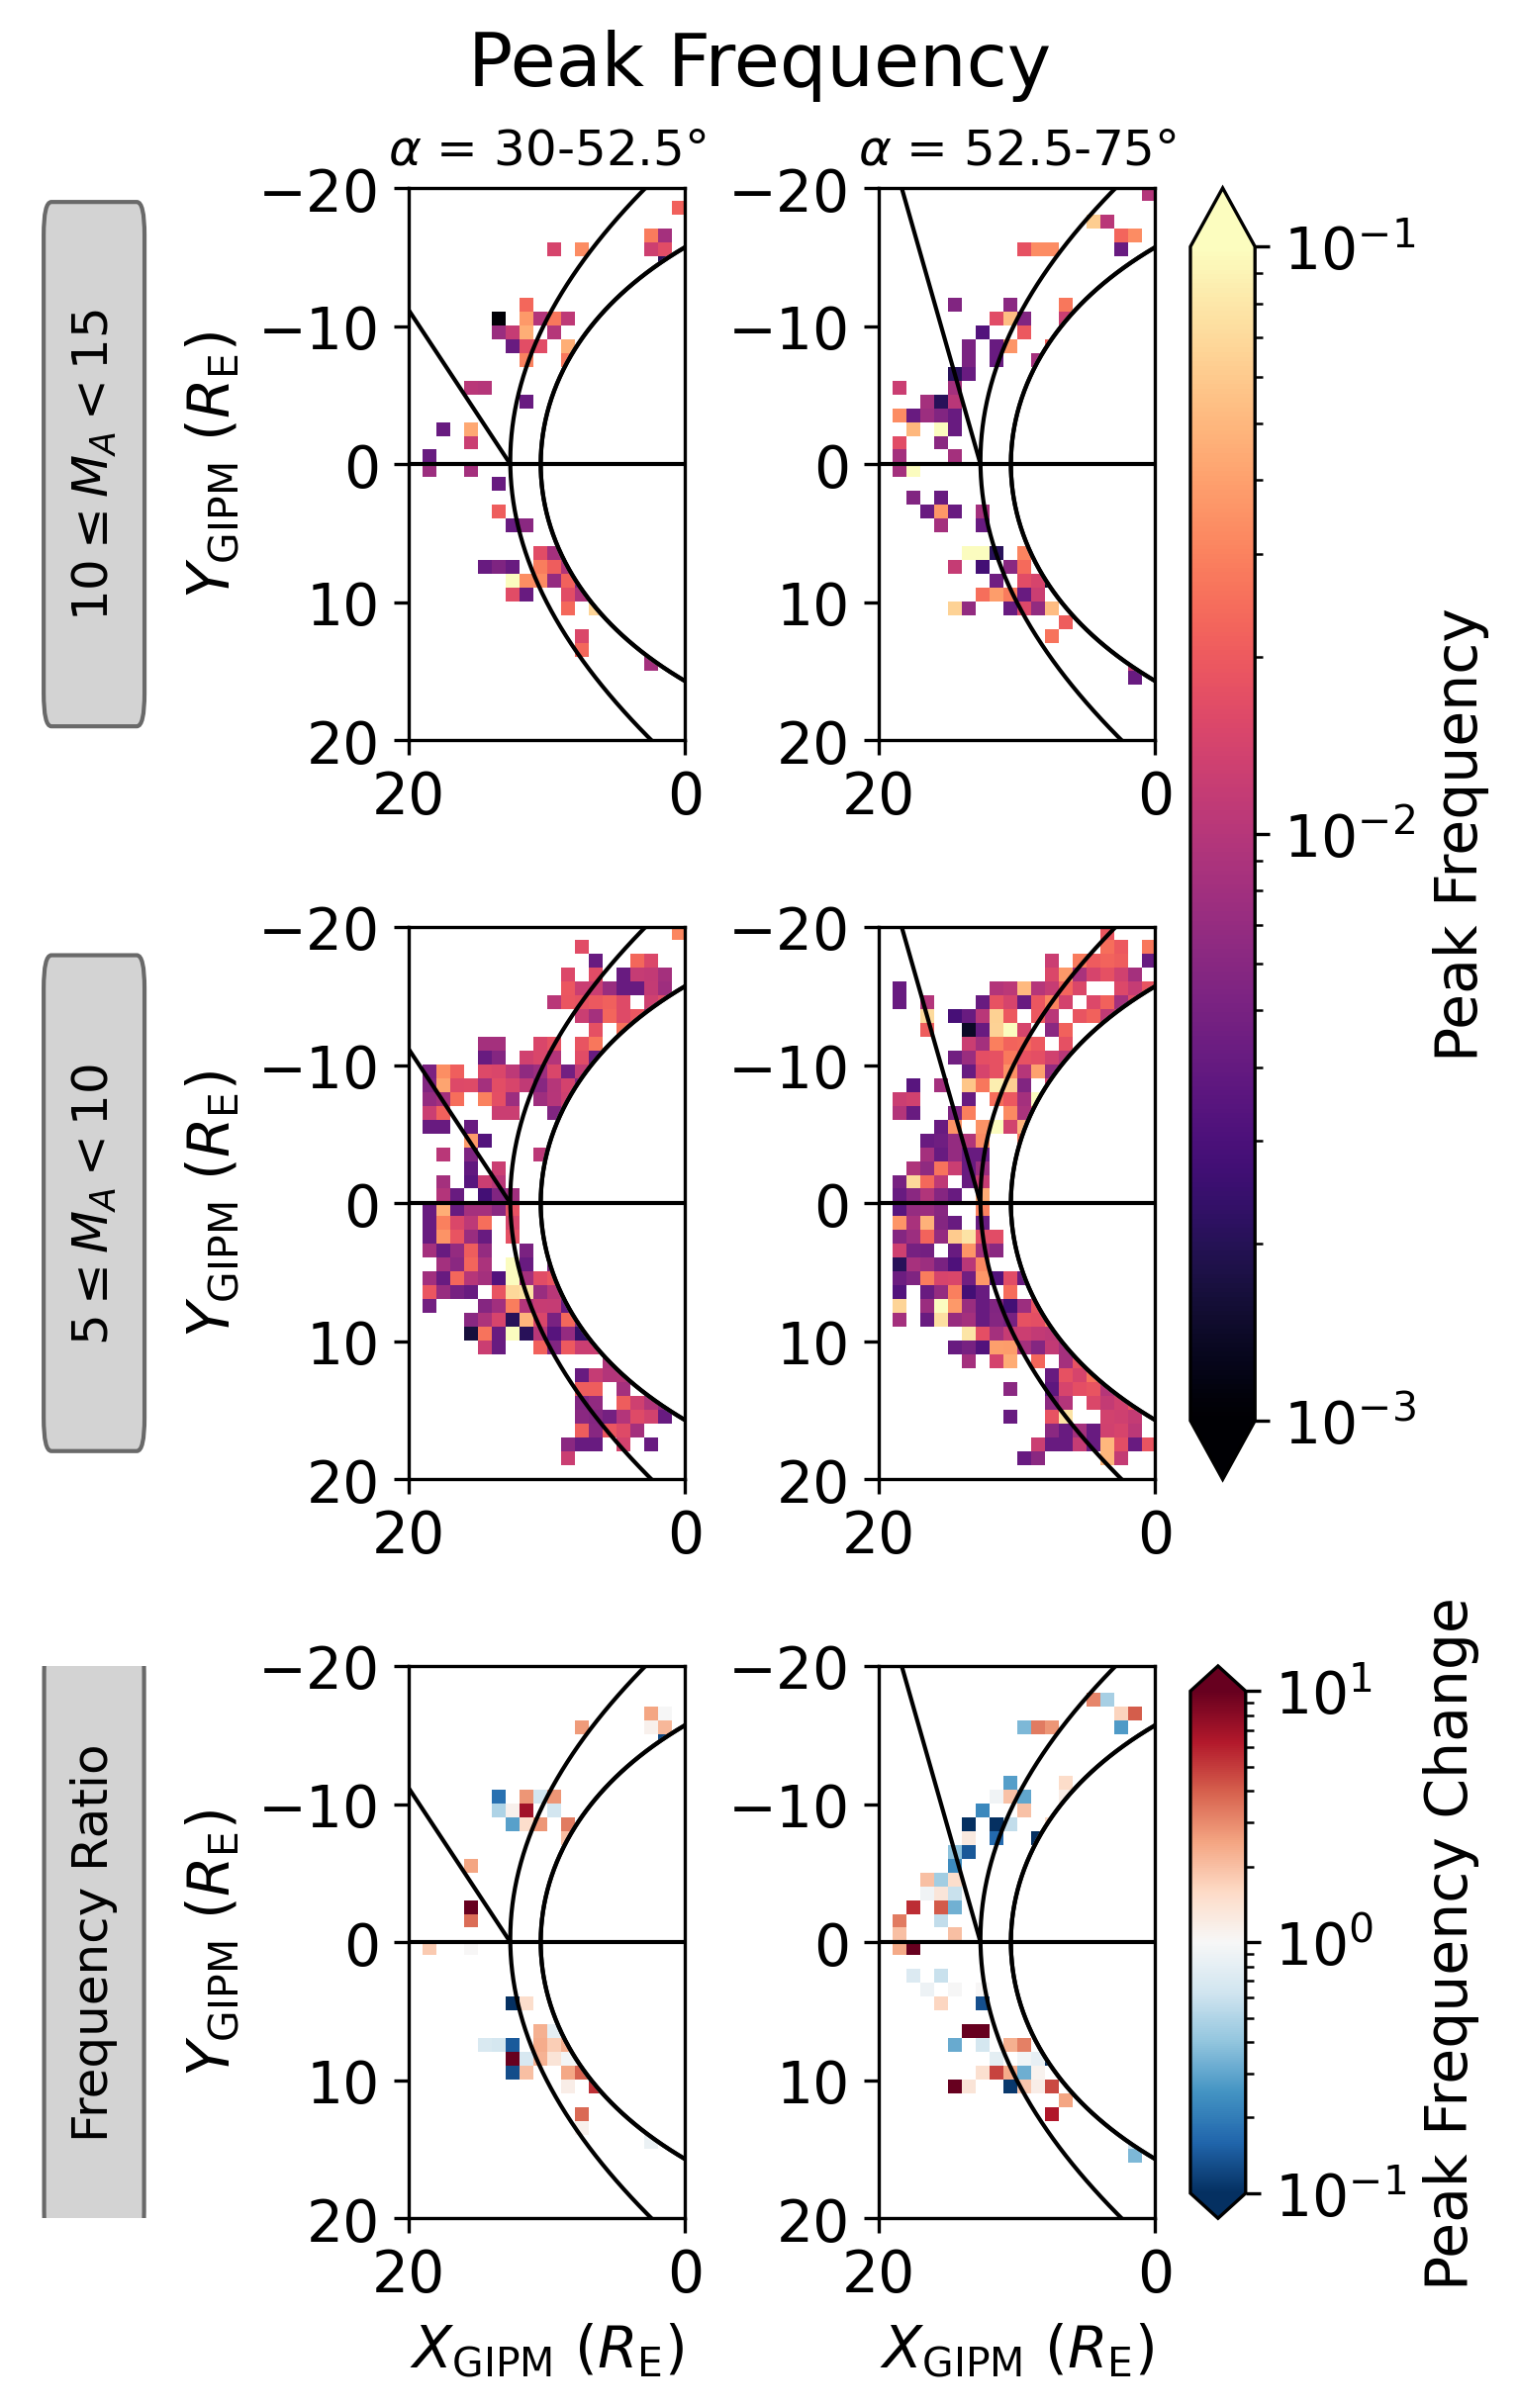

In [31]:
def draw_heatmap(ax, hist, extent, cmap, cmap_norm, angle_line):
    """Draw heatmap + flow line"""
    ax.imshow(hist, interpolation='none', origin='lower',
              extent=extent, cmap=cmap, norm=cmap_norm)
    
    x_s, x_e, y_s, y_e = angle_line
    ax.plot([x_s, x_e], [y_s, angle_line[3]], color='k', linewidth=1)

angle_titles_wide = ["30-52.5°", "52.5-75°"]
# -------------------------------
# CREATE FIGURE + GRID
# -------------------------------

fig = plt.figure(figsize=(5, 8), dpi=300, constrained_layout=True)
gs = fig.add_gridspec(
    nrows=3, ncols=3,      # 1 column for patch labels
    width_ratios=[0.35, 1, 1],  # label column thinner
    wspace=0.05, hspace=0.1
)

fig.suptitle("Peak Frequency", fontsize=18)
plt.rcParams['axes.labelsize'] = 14

# Row labels (top row → bottom row)
row_labels = [
    r'$10 \leq M_A < 15$',
    r'$5 \leq M_A < 10$',
    r'Frequency Ratio'
]

# -------------------------------
# MAKE AXES FOR THE 3×5 PANELS
# -------------------------------
axs = []
for r in range(3):
    plot_row_axes = []
    gs_row = r      
    for c in range(2):
        ax = fig.add_subplot(gs[gs_row, c + 1])
        plot_row_axes.append(ax)
    axs.append(plot_row_axes)

# -------------------------------
# Patch Labels (Rounded Boxes)
# -------------------------------

for r in range(3):
    ax_patch = fig.add_subplot(gs[r, 0])
    ax_patch.set_axis_off()

    # -- Draw text first so we can query its bounding box --
    txt = ax_patch.text(
        0.5, 0.5,                     # centered in the Axes
        row_labels[r],
        ha="center",
        va="center",
        fontsize=12,
        transform=ax_patch.transAxes,
        rotation='vertical'
    )

    fig.canvas.draw()  # required to obtain correct text bounding box

    # -- Convert text bounding box from display to Axes coordinates --
    renderer = fig.canvas.get_renderer()
    bbox = txt.get_window_extent(renderer=renderer)
    bbox_axes = TransformedBbox(
        bbox, ax_patch.transAxes.inverted()
    )

    # Add some padding around the text
    pad_x = 0.04   # fractional padding in axes coordinates
    pad_y = 0.01

    x0 = bbox_axes.x0 - pad_x
    y0 = bbox_axes.y0 - pad_y
    width = bbox_axes.width + 2 * pad_x
    height = bbox_axes.height + 2 * pad_y

    # -- Rounded box placed behind the text --
    box = FancyBboxPatch(
        (x0, y0),
        width,
        height,
        boxstyle="round,pad=0.2,rounding_size=0.06",
        fc="lightgrey",
        ec="dimgrey",
        linewidth=1,
        mutation_aspect=1,
        transform=ax_patch.transAxes,
        zorder=0.5,
    )
    ax_patch.add_patch(box)

    # Move text above box
    txt.set_zorder(1)


# -------------------------------
# COLORMAP
# -------------------------------

powercmp = 'magma'
power_norm = colors.LogNorm(vmin=0.001, vmax=0.1)
ratio_cmp = 'RdBu_r'
ratio_norm = colors.LogNorm(vmin=0.1, vmax=10)

# -------------------------------
# PLOT ALL PANELS
# -------------------------------

for col in range(2):                         # angle class
    title = angle_titles_wide[col]
    slope = line_slopes[title]
    y_e = -x_e * slope

    for row in range(3):                     # mach no. class
        ax = axs[row][col]

        # Draw contour, magnetopause
        draw_background(ax, Xgipm[:, :, 0], Ygipm[:, :, 0], f[:, :, 0],
                        X_shue, R_shue)

        # Histogram for this cell
        hist = freq_blocks[row][col]

        # angle line parameters: (x_s, x_e, y_s, y_e)
        angle_line = (x_s, x_e, y_s, y_e)

        if row < 2:
            draw_heatmap(ax, hist, extent, powercmp, power_norm, angle_line)

        if row == 2:
            draw_heatmap(ax, hist, extent, ratio_cmp, ratio_norm, angle_line)

        mask_inside_magnetopause(ax, X_shue, R_shue)
        
        # redraw magnetopause boundary so it stays crisp
        ax.plot(X_shue, R_shue, 'k', linewidth=1)
        
        set_limits(ax)
        
        # Labels
        if col == 0:
            ax.set_ylabel("$Y_\\mathrm{GIPM}$ ($R_\\mathrm{E}$)")
        if row == 0:
            ax.set_title(rf'$\alpha$ = {title}', fontsize=12)
        if row == 2:
            ax.set_xlabel("$X_\\mathrm{GIPM}$ ($R_\\mathrm{E}$)")

# -------------------------------
# COLORBARS (TWO SEPARATE ON RIGHT)
# -------------------------------

from matplotlib.cm import ScalarMappable

# --- Scalar mappables (independent of any single subplot image)
sm_power = ScalarMappable(norm=power_norm, cmap=powercmp)
sm_power.set_array([])

sm_ratio = ScalarMappable(norm=ratio_norm, cmap=ratio_cmp)
sm_ratio.set_array([])

# --- Top two rows colourbar (wave power)
top_axes = axs[0] + axs[1]   # flatten row 0 and 1
cbar1 = fig.colorbar(
    sm_power,
    ax=top_axes,
    location='right',
    pad=0.02,
    extend='both'
)
cbar1.set_label('Peak Frequency')

# --- Bottom row colourbar (ratio)
bottom_axes = axs[2]
cbar2 = fig.colorbar(
    sm_ratio,
    ax=bottom_axes,
    location='right',
    aspect=10,
    pad=0.02,
    extend='both'
)
cbar2.set_label('Peak Frequency Change')

cbar1.ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
cbar2.ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())


plt.show()


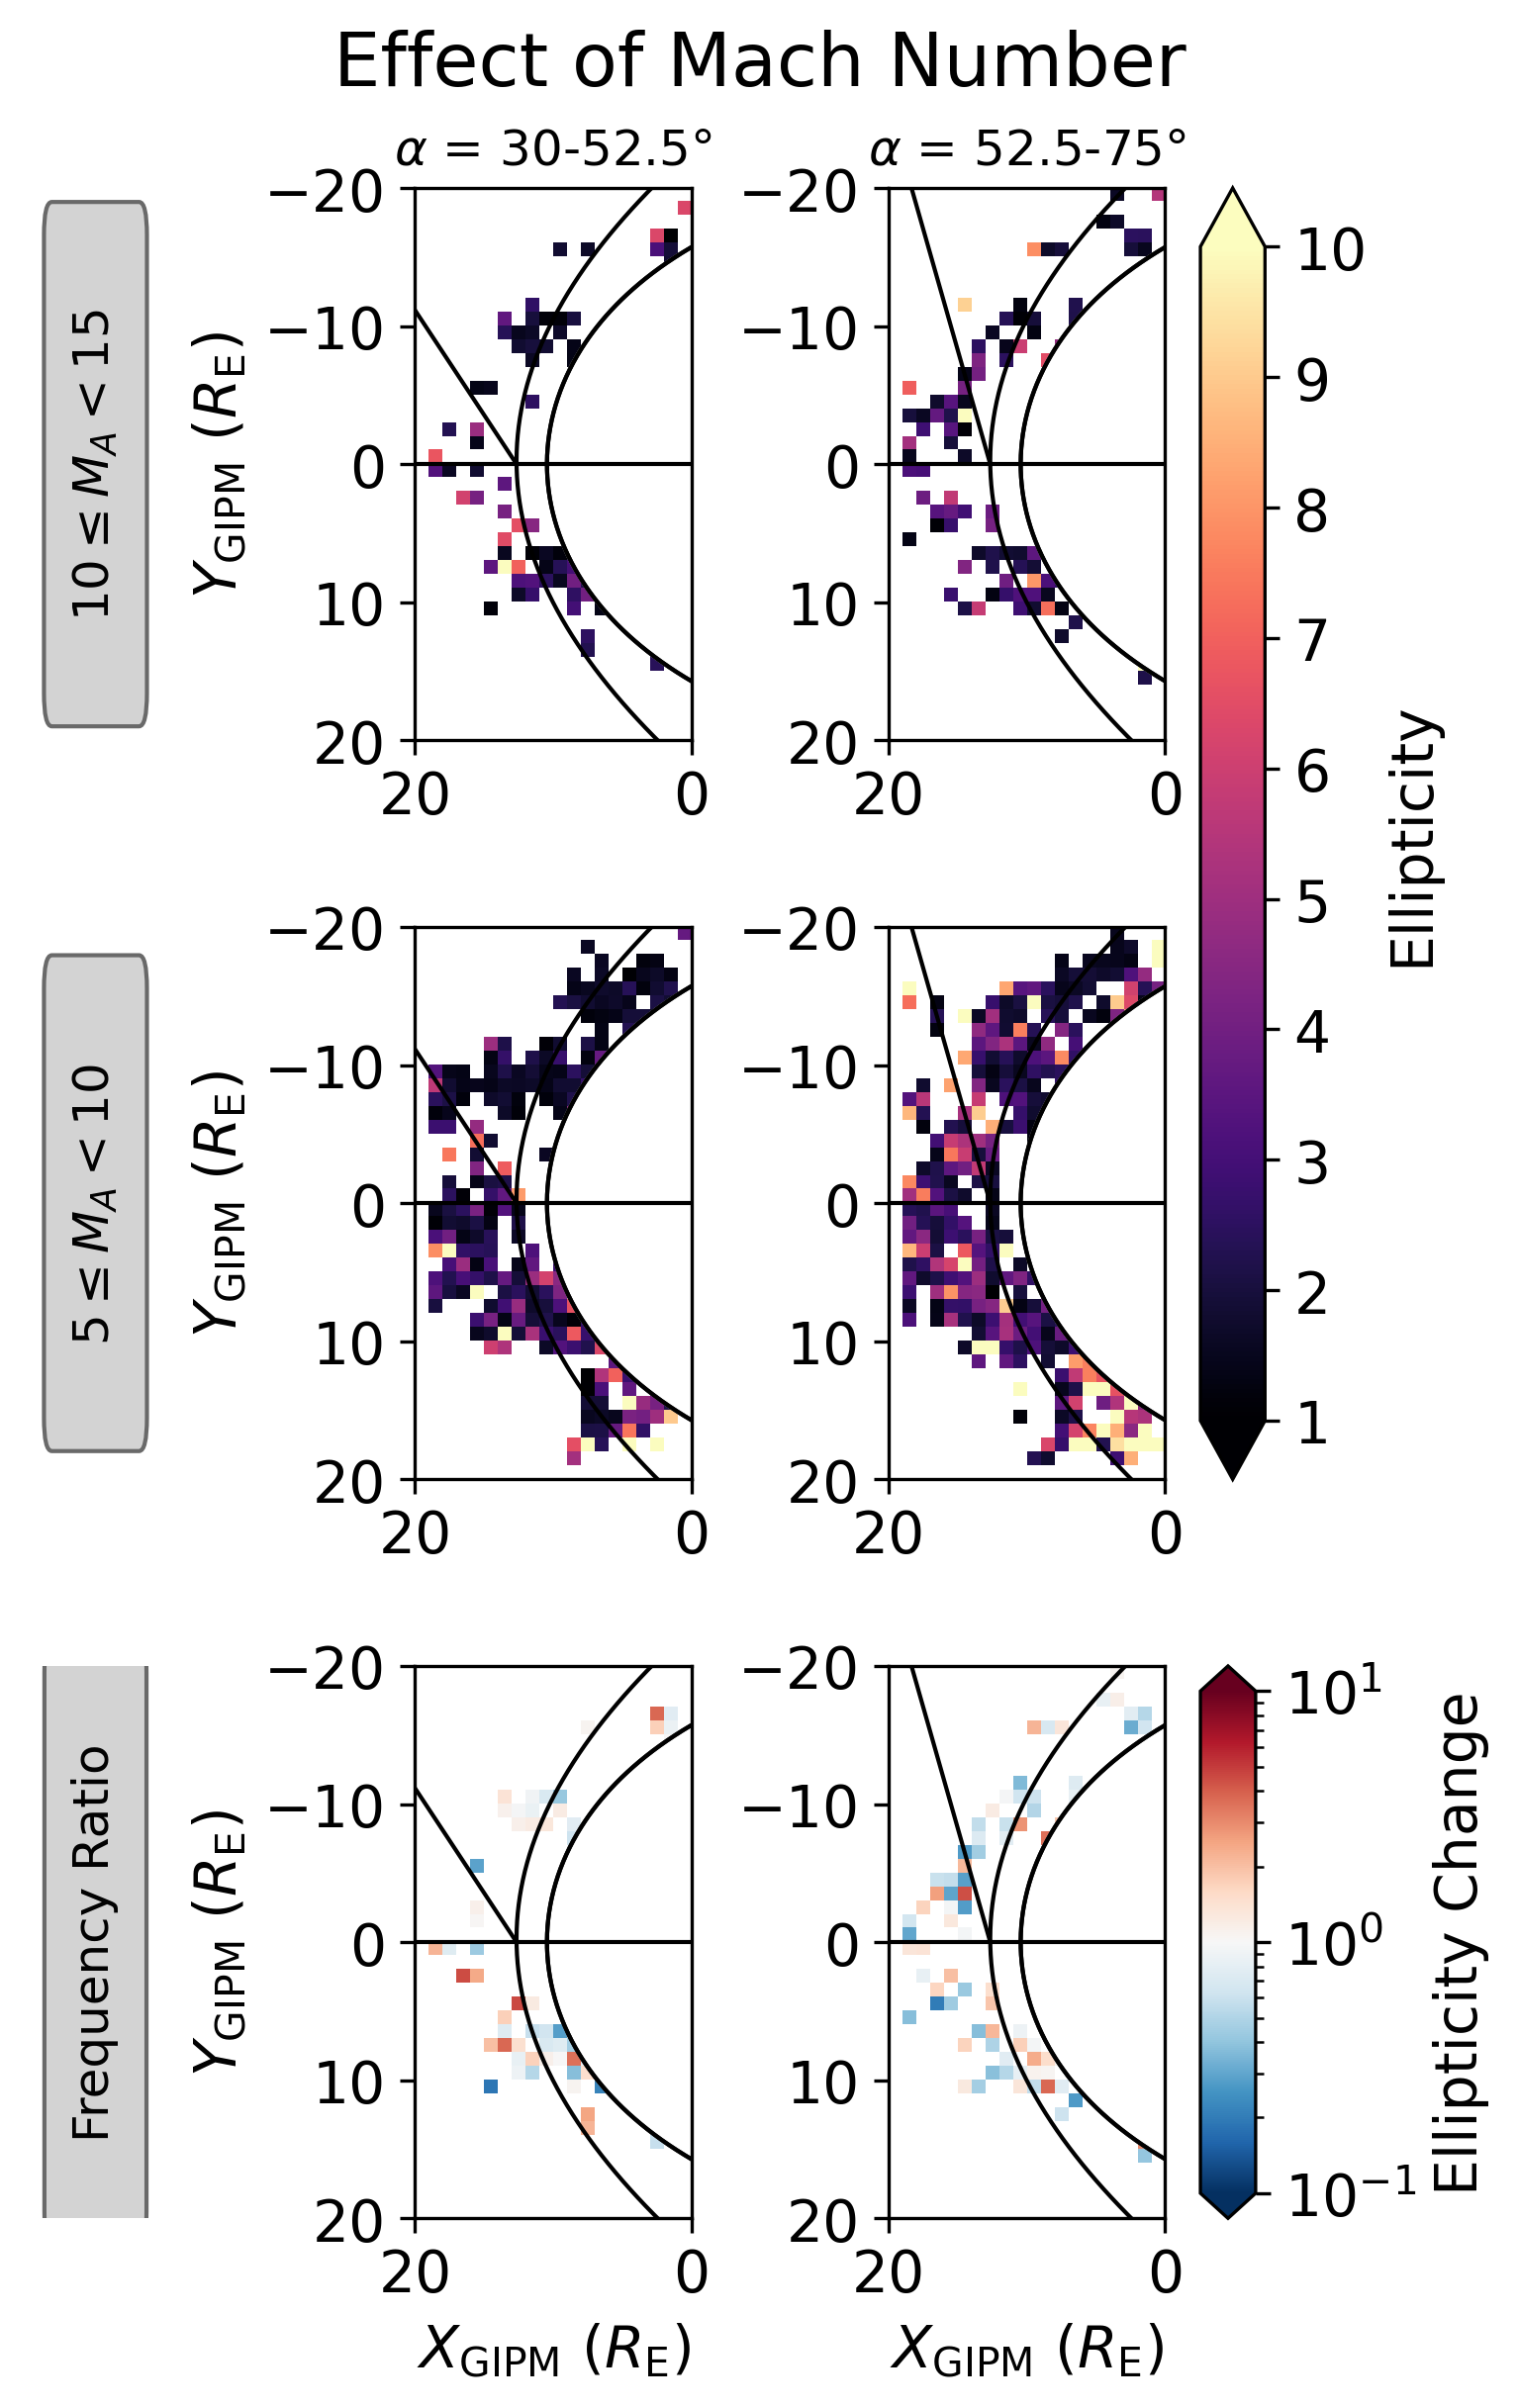

In [36]:
def draw_heatmap(ax, hist, extent, cmap, cmap_norm, angle_line):
    """Draw heatmap + flow line"""
    ax.imshow(hist, interpolation='none', origin='lower',
              extent=extent, cmap=cmap, norm=cmap_norm)
    
    x_s, x_e, y_s, y_e = angle_line
    ax.plot([x_s, x_e], [y_s, angle_line[3]], color='k', linewidth=1)

angle_titles_wide = ["30-52.5°", "52.5-75°"]
# -------------------------------
# CREATE FIGURE + GRID
# -------------------------------

fig = plt.figure(figsize=(5, 8), dpi=300, constrained_layout=True)
gs = fig.add_gridspec(
    nrows=3, ncols=3,      # 1 column for patch labels
    width_ratios=[0.35, 1, 1],  # label column thinner
    wspace=0.05, hspace=0.1
)

fig.suptitle("Effect of Mach Number", fontsize=18)
plt.rcParams['axes.labelsize'] = 14

# Row labels (top row → bottom row)
row_labels = [
    r'$10 \leq M_A < 15$',
    r'$5 \leq M_A < 10$',
    r'Frequency Ratio'
]

# -------------------------------
# MAKE AXES FOR THE 3×5 PANELS
# -------------------------------
axs = []
for r in range(3):
    plot_row_axes = []
    gs_row = r      
    for c in range(2):
        ax = fig.add_subplot(gs[gs_row, c + 1])
        plot_row_axes.append(ax)
    axs.append(plot_row_axes)

# -------------------------------
# Patch Labels (Rounded Boxes)
# -------------------------------

for r in range(3):
    ax_patch = fig.add_subplot(gs[r, 0])
    ax_patch.set_axis_off()

    # -- Draw text first so we can query its bounding box --
    txt = ax_patch.text(
        0.5, 0.5,                     # centered in the Axes
        row_labels[r],
        ha="center",
        va="center",
        fontsize=12,
        transform=ax_patch.transAxes,
        rotation='vertical'
    )

    fig.canvas.draw()  # required to obtain correct text bounding box

    # -- Convert text bounding box from display to Axes coordinates --
    renderer = fig.canvas.get_renderer()
    bbox = txt.get_window_extent(renderer=renderer)
    bbox_axes = TransformedBbox(
        bbox, ax_patch.transAxes.inverted()
    )

    # Add some padding around the text
    pad_x = 0.04   # fractional padding in axes coordinates
    pad_y = 0.01

    x0 = bbox_axes.x0 - pad_x
    y0 = bbox_axes.y0 - pad_y
    width = bbox_axes.width + 2 * pad_x
    height = bbox_axes.height + 2 * pad_y

    # -- Rounded box placed behind the text --
    box = FancyBboxPatch(
        (x0, y0),
        width,
        height,
        boxstyle="round,pad=0.2,rounding_size=0.06",
        fc="lightgrey",
        ec="dimgrey",
        linewidth=1,
        mutation_aspect=1,
        transform=ax_patch.transAxes,
        zorder=0.5,
    )
    ax_patch.add_patch(box)

    # Move text above box
    txt.set_zorder(1)


# -------------------------------
# COLORMAP
# -------------------------------

powercmp = 'magma'
power_norm = colors.Normalize(vmin=1, vmax=10)
ratio_cmp = 'RdBu_r'
ratio_norm = colors.LogNorm(vmin=0.1, vmax=10)

# -------------------------------
# PLOT ALL PANELS
# -------------------------------

for col in range(2):                         # angle class
    title = angle_titles_wide[col]
    slope = line_slopes[title]
    y_e = -x_e * slope

    for row in range(3):                     # mach no. class
        ax = axs[row][col]

        # Draw contour, magnetopause
        draw_background(ax, Xgipm[:, :, 0], Ygipm[:, :, 0], f[:, :, 0],
                        X_shue, R_shue)

        # Histogram for this cell
        hist = ellipticity_blocks[row][col]

        # angle line parameters: (x_s, x_e, y_s, y_e)
        angle_line = (x_s, x_e, y_s, y_e)

        if row < 2:
            draw_heatmap(ax, hist, extent, powercmp, power_norm, angle_line)

        if row == 2:
            draw_heatmap(ax, hist, extent, ratio_cmp, ratio_norm, angle_line)

        mask_inside_magnetopause(ax, X_shue, R_shue)
        
        # redraw magnetopause boundary so it stays crisp
        ax.plot(X_shue, R_shue, 'k', linewidth=1)
        
        set_limits(ax)
        
        # Labels
        if col == 0:
            ax.set_ylabel("$Y_\\mathrm{GIPM}$ ($R_\\mathrm{E}$)")
        if row == 0:
            ax.set_title(rf'$\alpha$ = {title}', fontsize=12)
        if row == 2:
            ax.set_xlabel("$X_\\mathrm{GIPM}$ ($R_\\mathrm{E}$)")

# -------------------------------
# COLORBARS (TWO SEPARATE ON RIGHT)
# -------------------------------

from matplotlib.cm import ScalarMappable

# --- Scalar mappables (independent of any single subplot image)
sm_power = ScalarMappable(norm=power_norm, cmap=powercmp)
sm_power.set_array([])

sm_ratio = ScalarMappable(norm=ratio_norm, cmap=ratio_cmp)
sm_ratio.set_array([])

# --- Top two rows colourbar (wave power)
top_axes = axs[0] + axs[1]   # flatten row 0 and 1
cbar1 = fig.colorbar(
    sm_power,
    ax=top_axes,
    location='right',
    pad=0.02,
    extend='both'
)
cbar1.set_label('Ellipticity')

# --- Bottom row colourbar (ratio)
bottom_axes = axs[2]
cbar2 = fig.colorbar(
    sm_ratio,
    ax=bottom_axes,
    location='right',
    aspect=10,
    pad=0.02,
    extend='both'
)
cbar2.set_label('Ellipticity Change')

cbar2.ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())


plt.show()


In [8]:
c1_file_list_2002 = []
c2_file_list_2002 = []
c3_file_list_2002 = []
c4_file_list_2002 = []

path = "/Users/roseatkinson/Documents/Cluster_Integrated_CSVs/Integrated_CSVs_2002/**"

for path in glob.glob(path, recursive=True):
    if '.csv' in path:
        if 'C1' in path:
            c1_file_list_2002.append(path)
        if 'C2' in path:
            c2_file_list_2002.append(path)   
        if 'C3' in path:
            c3_file_list_2002.append(path)
        if 'C4' in path:
            c4_file_list_2002.append(path)

cl_csvs_2002 = [c1_file_list_2002, c2_file_list_2002, c3_file_list_2002, c4_file_list_2002]


c1_dfs_2002 = []
c2_dfs_2002 = []
c3_dfs_2002 = []
c4_dfs_2002 = []

cl_dfs_2002 = [c1_dfs_2002, c2_dfs_2002, c3_dfs_2002, c4_dfs_2002]

for csv_list, df_list in zip(cl_csvs_2002, cl_dfs_2002):
    for file in csv_list:
        df = pd.read_csv(file,encoding='utf-8')
        df['datetime'] = pd.to_datetime(df['datetime'], format='mixed')
        df.set_index('datetime', inplace = True)
        df_list.append(df)

cl_1_df_2002 = pd.concat(c1_dfs_2002)
cl_2_df_2002 = pd.concat(c2_dfs_2002)
cl_3_df_2002 = pd.concat(c3_dfs_2002)
cl_4_df_2002 = pd.concat(c4_dfs_2002)

#Filtering: remove OMNI too far, current sheets, & null GIPM entries
cl_1_filtered_2002 = cl_1_df_2002.loc[cl_1_df_2002['ULF Band Compressive Power'].notnull()]
cl_2_filtered_2002 = cl_2_df_2002.loc[cl_2_df_2002['ULF Band Compressive Power'].notnull()]
cl_3_filtered_2002 = cl_3_df_2002.loc[cl_3_df_2002['ULF Band Compressive Power'].notnull()]
cl_4_filtered_2002 = cl_4_df_2002.loc[cl_4_df_2002['ULF Band Compressive Power'].notnull()]


In [9]:
cl_1_filtered_2002.describe()

,GIPM X (OMNI mean),GIPM Y (OMNI mean),GIPM Z (OMNI mean),GIPM X (OMNI median),GIPM Y (OMNI median),GIPM Z (OMNI median),B min/Bomni,B mean/Bomni,B max/Bomni,B median/Bomni,...,IMF V (median),IMF Np (mean),IMF Np (median),OMNI Dist from X line (mean),OMNI Dist from X line (median),Max IMF Deviation,ULF Band Compressive Power,ULF Band Transverse Power,ULF Band Normalised Compressive Power,ULF Band Normalised Transverse Power
count,2.577800e+04,25778.000000,25778.000000,25778.000000,25778.000000,25778.000000,25778.000000,25778.000000,25778.000000,25778.000000,...,25778.000000,25778.000000,25778.000000,25778.000000,25778.000000,25778.000000,27661.000000,27661.000000,2.766100e+04,2.766100e+04
mean,6.200798e+00,1.306246,0.355782,6.200425,1.268633,0.354519,2.840263,3.864185,4.837542,3.870700,...,443.356738,6.512205,6.501111,45.517802,45.516631,32.649539,5.837531,10.746642,1.432207e-02,3.076048e-02
std,4.324976e+00,9.015436,8.151597,4.321322,9.003012,8.162132,3.499711,3.363175,3.521722,3.379687,...,88.614563,5.438079,5.442260,62.423608,62.424081,26.666784,17.082979,25.970912,3.294524e-02,6.231335e-02
min,3.232993e-07,-22.548209,-22.623758,0.000200,-22.380588,-21.903876,0.005891,0.396270,0.656404,0.374942,...,256.300000,0.032000,0.030000,0.090388,0.090554,0.000000,0.000036,0.000158,8.418552e-09,7.280285e-08
25%,2.707591e+00,-6.158900,-6.598848,2.698744,-6.179188,-6.594912,0.784758,1.357867,2.308980,1.271374,...,380.200000,3.532589,3.520000,19.974394,19.976991,13.818614,0.053672,0.415095,1.826874e-04,1.468595e-03
50%,5.614620e+00,1.780921,0.863492,5.616290,1.706184,0.904654,1.871020,3.140366,4.175376,3.142021,...,429.700000,4.741000,4.730000,30.589808,30.589281,25.230211,0.745950,2.496618,1.943456e-03,6.656929e-03
75%,8.599612e+00,8.647793,7.242870,8.590961,8.615309,7.231604,2.977923,4.292376,6.065053,4.324562,...,493.437500,7.364000,7.350000,41.016960,41.017114,43.296496,4.232329,8.704359,1.152456e-02,2.741320e-02
max,2.088945e+01,22.240325,22.170136,20.885394,22.488239,21.876034,34.981476,35.240150,35.448592,35.251543,...,809.500000,67.826000,68.485000,323.284735,323.284735,179.395676,609.270118,719.242837,5.366587e-01,1.042090e+00


In [ ]:
c1_file_list_2003 = []
c2_file_list_2003 = []
c3_file_list_2003 = []
c4_file_list_2003 = []

path = "/Users/roseatkinson/Documents/Cluster_Integrated_CSVs/Integrated_CSVs_2003/**"

for path in glob.glob(path, recursive=True):
    if '.csv' in path:
        if 'C1' in path:
            c1_file_list_2003.append(path)
        if 'C2' in path:
            c2_file_list_2003.append(path)   
        if 'C3' in path:
            c3_file_list_2003.append(path)
        if 'C4' in path:
            c4_file_list_2003.append(path)

cl_csvs_2003 = [c1_file_list_2003, c2_file_list_2003, c3_file_list_2003, c4_file_list_2003]